# Is Malaysia Winning Share? The Local Picture

## The Question

Notebook 02 found Japan's investment into ASEAN as a whole has fallen 57% since 2019. Yet Malaysia's own investment authority (MIDA) reported Japan as its single largest source of approved investment in Q1 2026 — a 13.8x year-on-year surge. Is Malaysia genuinely bucking the regional trend and winning outsized share, or is this one quarter's noise?

## The Answer

The Japan number is real and dramatic — RM21.5 billion in Q1 2026, up from just RM1.6 billion in Q1 2025, concentrated overwhelmingly (93.6%) in digital transformation and data-centre investment. That is a genuine, large, specific local capture story, not noise: it lines up with Malaysia being named one of UNCTAD's top ten global data-centre investment destinations in the same period. China's investment into Malaysia tells a messier story: it peaked at RM55.4 billion in 2022 (over a third of all approved foreign investment that year), fell sharply to RM14.5 billion in 2023, then partially recovered to RM28.2 billion in 2024 — a trajectory that does not cleanly support either "China is aggressively relocating into Malaysia" or "China has lost interest," and part of the 2023 dip is likely a methodology change (MIDA only formalized "ultimate source" attribution in December 2023), not a real collapse in Chinese interest. The honest read: Malaysia has one clear, recent, dramatic capture story (Japan, digital infrastructure) and one much noisier, harder-to-interpret one (China).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

malaysia_fdi = pd.read_csv('../data/processed/malaysia_fdi_by_source.csv')
malaysia_fdi

,source_country,period,period_type,fdi_approved_rm_billion,note
0,China,2022,FY,55.4,33.9% of total approved FI that year - China w...
1,China,2023,FY,14.5,Sharp drop from 2022; Netherlands (35.5) and C...
2,China,2024,FY,28.2,Third-largest source that year
3,China,2026,Q1,10.1,NaN
4,Japan,2023,H1,9.1,"First-half 2023 figure only, not comparable to..."
5,Japan,2025,Q1,1.6,Base period for the Q1 2026 surge figure below
6,Japan,2026,Q1,21.5,13.8x year-on-year surge vs. Q1 2025; largest ...
7,United States,2023,FY,21.5,NaN
8,United States,2024,FY,32.8,Largest single source that year
9,United States,2026,Q1,10.1,NaN


In [2]:
# House chart style v2 — consulting-exhibit conventions (MBB-style):
# gray for context series, one or two accent colors for what the title is
# actually about, direct end-of-line/bar labels instead of a legend box.
ACCENT_1 = '#2a78d6'   # primary accent — the series the title is about
ACCENT_2 = '#eb6834'   # secondary accent — used only for genuine two-way comparisons
                        # or a title that names two co-equal findings
GRAY = '#9a9a95'        # de-emphasized / context series — same family, faded out
INK, INK_SECONDARY, INK_MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURFACE = '#ececea', '#fcfcfb'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'text.color': INK,
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': INK_SECONDARY,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'axes.grid.axis': 'y',
    'grid.color': GRID,
    'grid.linewidth': 0.7,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'legend.frameon': False,
})

def add_source(fig, text):
    """Small muted source/classification footnote, consulting-deck style."""
    fig.text(0.01, -0.04, text, ha='left', va='top', fontsize=8.5,
              color=INK_MUTED, style='italic', transform=fig.transFigure)

def end_label(ax, x, y, text, color, weight='semibold', va='center', offset=8):
    """Direct label at a line's endpoint, replacing a legend box."""
    ax.annotate(text, xy=(x, y), xytext=(offset, 0), textcoords='offset points',
                 va=va, ha='left', fontsize=10.5, fontweight=weight, color=color)


## Japan's investment into Malaysia specifically: the sharpest data point in this case study

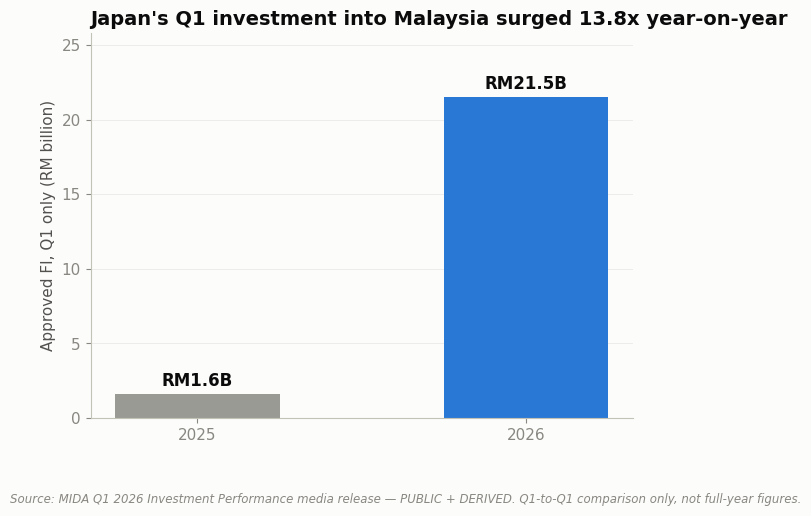

In [3]:
japan = malaysia_fdi[malaysia_fdi['source_country'] == 'Japan'].set_index('period')['fdi_approved_rm_billion']

fig, ax = plt.subplots(figsize=(7, 5))
periods = ['2025', '2026']
values = [japan.loc[2025], japan.loc[2026]]
bars = ax.bar(periods, values, color=[GRAY, ACCENT_1], width=0.5, edgecolor='none')
for bar, v in zip(bars, values):
    ax.annotate(f'RM{v:.1f}B', xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 6), textcoords='offset points', ha='center', fontsize=12, fontweight='semibold')

ax.set_title("Japan's Q1 investment into Malaysia surged 13.8x year-on-year", loc='left')
ax.set_ylabel('Approved FI, Q1 only (RM billion)')
ax.set_xlabel('')
ax.set_ylim(top=max(values) * 1.2)

add_source(ax.figure, 'Source: MIDA Q1 2026 Investment Performance media release — PUBLIC + DERIVED. '
                       'Q1-to-Q1 comparison only, not full-year figures.')
plt.show()

## China's investment into Malaysia: a noisier, three-year story

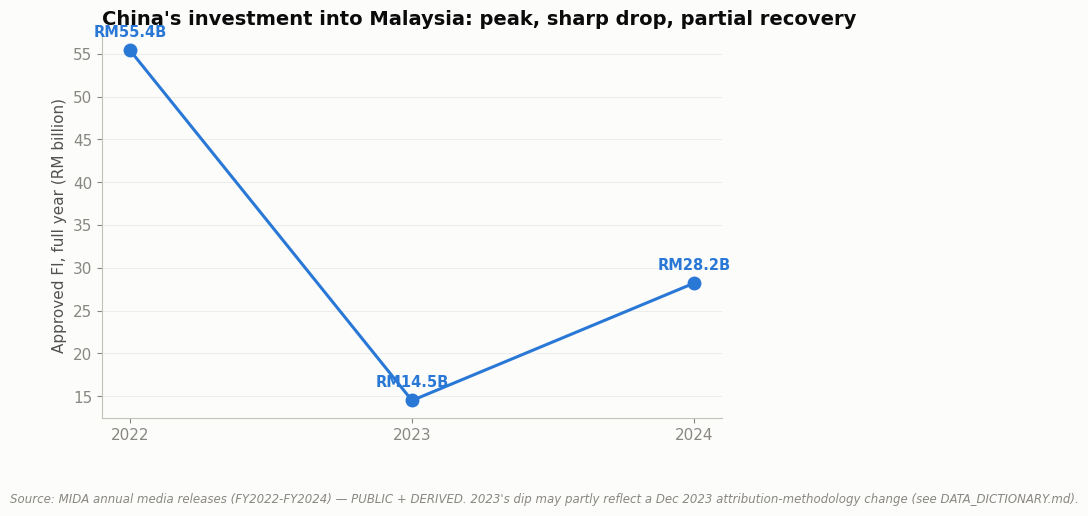

In [4]:
china = malaysia_fdi[malaysia_fdi['source_country'] == 'China'].set_index('period')['fdi_approved_rm_billion']
china_fy = china.drop(2026)  # keep only the three full-year points for this chart

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(china_fy.index, china_fy.values, marker='o', markersize=9, linewidth=2.2, color=ACCENT_1)
for yr, v in china_fy.items():
    ax.annotate(f'RM{v:.1f}B', xy=(yr, v), xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=10.5, fontweight='semibold', color=ACCENT_1)

ax.set_title("China's investment into Malaysia: peak, sharp drop, partial recovery", loc='left')
ax.set_ylabel('Approved FI, full year (RM billion)')
ax.set_xlabel('')
ax.set_xticks([2022, 2023, 2024])

add_source(ax.figure, "Source: MIDA annual media releases (FY2022-FY2024) — PUBLIC + DERIVED. 2023's dip may "
                       "partly reflect a Dec 2023 attribution-methodology change (see DATA_DICTIONARY.md).")
plt.show()


## Strategic Recommendation

- **Businesses tracking Japan-Malaysia investment ties should treat the digital infrastructure/data-centre surge as the real, current story** — it is large, recent, concentrated in a specific sector, and consistent with independent UNCTAD reporting naming Malaysia a top-ten global data-centre destination in the same period.
- **China-Malaysia investment figures should not be read as a single clean trend line.** The 2022 peak, 2023 collapse, and 2024 partial recovery likely mix real investment behaviour with a genuine methodology change — a business should ask MIDA or a primary source for like-for-like figures before drawing conclusions from the headline numbers alone.
- **Combining all three notebooks: the "China+1 diversification into Malaysia" story is real but narrower and more sector-specific than the popular framing suggests.** It is not a broad-based reshoring wave; it is a mix of (a) Chinese firms themselves relocating into the region (Notebook 02), and (b) Malaysia specifically winning a concentrated, recent surge in Japanese digital-infrastructure investment — two different mechanisms, not one simple trend.

## Confidence & Caveats

- **This dataset is the least consistent in the case study, by necessity of what MIDA actually published** — full-year, half-year, and single-quarter figures are mixed together and not directly comparable to each other. See `DATA_DICTIONARY.md` for exactly which period each number covers.
- **"Approved" investment (MIDA's FI measure) is not realized capital.** MIDA states approved projects typically take 18–24 months to be implemented — none of the figures in this notebook represent money that has actually landed in Malaysia yet.
- **The China 2023 dip is explicitly flagged, not resolved.** This analysis cannot separate how much of the RM55.4B → RM14.5B drop was real investor pullback versus a reporting-methodology change, because MIDA's own explainer of the change was published alongside the Q1 2026 release, not alongside the 2023 or 2024 figures themselves.
- **One quarter (Q1 2026) is doing a lot of work in the Japan finding.** A single strong quarter is a real, large, verifiable data point — but it is not yet a multi-year trend the way the ASEAN-regional or global figures in Notebooks 01–02 are.